In [2]:
import os
import numpy as np
import pandas as pd

os.makedirs("data", exist_ok=True)
os.makedirs("outputs", exist_ok=True)
rng = np.random.default_rng(42)
n = 1000

branch = rng.choice(["CSE", "IT", "ECE", "EEE", "ME", "CE"], n, p=[.28, .20, .20, .10, .12, .10])
cgpa = np.clip(rng.normal(7.4, 1.0, n), 4.5, 10)
internships = np.clip(rng.poisson(0.9, n), 0, 4)
projects = np.clip(rng.poisson(2.0, n), 0, 8)
certs = np.clip(rng.poisson(1.5, n), 0, 6)
aptitude = np.clip(rng.normal(60 + 4 * (cgpa - 7.4), 12), 10, 100).round(1)
is_cs = np.isin(branch, ["CSE", "IT"]).astype(int)
coding = np.clip(rng.normal(55 + 5 * (cgpa - 7.4) + 10 * is_cs, 15), 5, 100).round(1)
comm = np.clip(np.round(rng.normal(6, 1.7, n)), 1, 10)
backlogs = np.clip(rng.poisson(np.maximum(0.05, (8 - cgpa) * 0.4)), 0, 5)
extra = rng.random(n) < 0.5

z = (1.0 * (cgpa - 7.4) + 0.5 * internships + 0.15 * projects + 0.1 * certs
     + 0.03 * (aptitude - 60) + 0.03 * (coding - 55) + 0.15 * (comm - 6)
     - 0.8 * backlogs + 0.3 * extra - 0.45 + rng.normal(0, 0.8, n))
placed = (rng.random(n) < 1 / (1 + np.exp(-z))).astype(int)

df = pd.DataFrame({
    "student_id": np.arange(1, n + 1), "branch": branch, "cgpa": cgpa.round(2),
    "internships": internships, "projects": projects, "certifications": certs,
    "aptitude_score": aptitude, "coding_score": coding, "communication_skill": comm,
    "backlogs": backlogs, "extracurricular": np.where(extra, "Yes", "No"), "placed": placed,
})

# inject real-world mess
df["branch"] = df["branch"].astype(object)
idx = rng.choice(n, 120, replace=False)
df.loc[idx[:40], "branch"] = df.loc[idx[:40], "branch"].str.lower()
df.loc[idx[40:80], "branch"] = df.loc[idx[40:80], "branch"] + " "
df.loc[idx[80:], "branch"] = df.loc[idx[80:], "branch"].replace({"CSE": "Computer Science", "ECE": "Electronics"})

ex = df["extracurricular"].astype(object)
j = rng.choice(n, 150, replace=False)
ex.iloc[j[:50]] = ex.iloc[j[:50]].map({"Yes": "Y", "No": "N"})
ex.iloc[j[50:100]] = ex.iloc[j[50:100]].map({"Yes": "yes", "No": "no"})
df["extracurricular"] = ex

for col, frac in [("cgpa", .05), ("aptitude_score", .05), ("communication_skill", .04),
                  ("branch", .03), ("coding_score", .04), ("internships", .02)]:
    df.loc[rng.choice(n, int(frac * n), replace=False), col] = np.nan

df.loc[rng.choice(n, 14, replace=False), "cgpa"] = (df["cgpa"].mean() * 9.5).round(0)
df.loc[rng.choice(n, 8, replace=False), "aptitude_score"] = -1
df.loc[rng.choice(n, 5, replace=False), "backlogs"] = -2
df = pd.concat([df, df.sample(12, random_state=1)], ignore_index=True)

df.to_csv("data/placement_data.csv", index=False)
print(df.shape)


(1012, 12)


Raw data: (1012, 12)
After cleaning: (1000, 12) placed rate = 54.00%

=== Logistic Regression ===
              precision    recall  f1-score   support

  Not placed       0.73      0.59      0.65        92
      Placed       0.70      0.81      0.75       108

    accuracy                           0.71       200
   macro avg       0.71      0.70      0.70       200
weighted avg       0.71      0.71      0.71       200



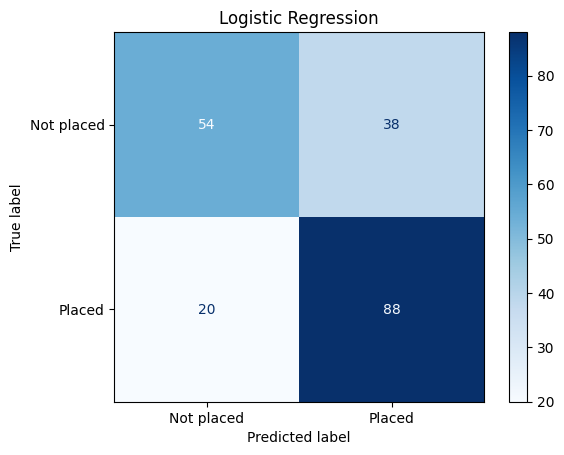

=== Random Forest ===
              precision    recall  f1-score   support

  Not placed       0.69      0.62      0.65        92
      Placed       0.70      0.76      0.73       108

    accuracy                           0.69       200
   macro avg       0.69      0.69      0.69       200
weighted avg       0.69      0.69      0.69       200



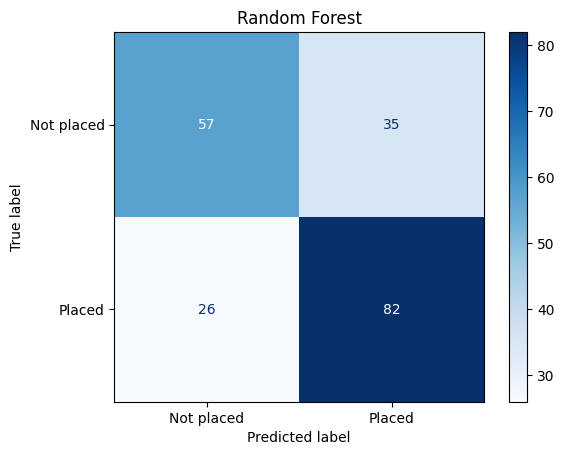

              model  cv_f1_train  test_precision  test_recall  test_f1
Logistic Regression        0.732           0.698        0.815    0.752
      Random Forest        0.738           0.701        0.759    0.729

Selected model (highest CV F1): Random Forest


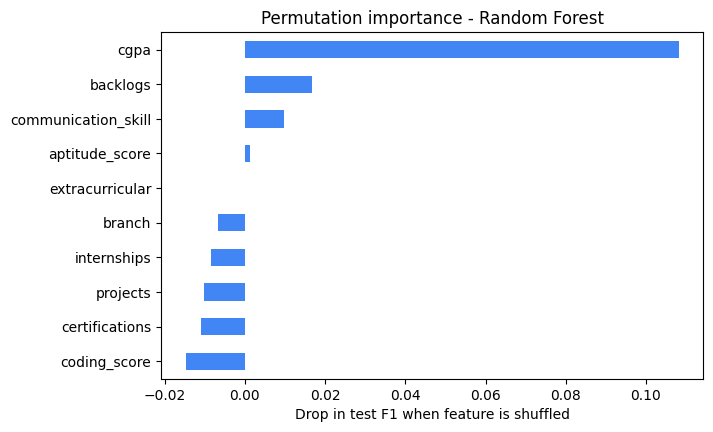


Example student probability of placement: 39.9% -> Not placed


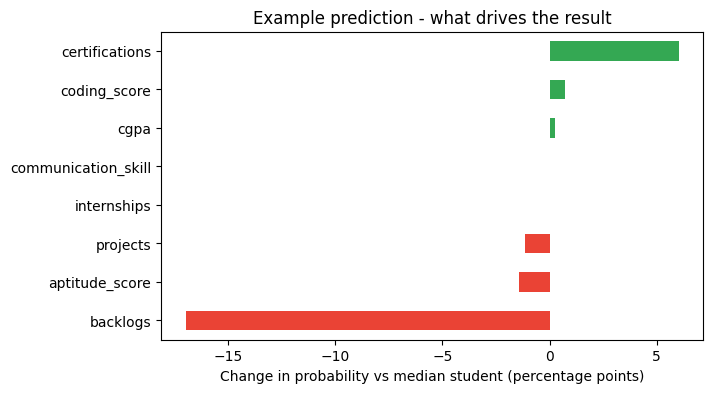

In [3]:
import json, warnings
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (ConfusionMatrixDisplay, classification_report,
                             f1_score, precision_score, recall_score)
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore")
SEED = 42
OUT = Path("outputs")
OUT.mkdir(exist_ok=True)

# ---------------- CONFIG ----------------
TARGET = "placed"
CATEGORICAL = ["branch", "extracurricular"]
NUMERIC = ["cgpa", "internships", "projects", "certifications", "aptitude_score",
           "coding_score", "communication_skill", "backlogs"]
VALID_RANGES = {"cgpa": (0, 10), "aptitude_score": (0, 100), "coding_score": (0, 100),
                "communication_skill": (1, 10), "internships": (0, 20), "projects": (0, 50),
                "certifications": (0, 50), "backlogs": (0, 30)}
BRANCH_MAP = {"computer science": "CSE", "cse": "CSE", "it": "IT", "electronics": "ECE",
              "ece": "ECE", "eee": "EEE", "me": "ME", "ce": "CE"}
YES_NO = {"y": "Yes", "yes": "Yes", "n": "No", "no": "No"}


def clean(df):
    df = df.drop_duplicates().copy()
    df = df.dropna(subset=[TARGET])
    df["branch"] = (df["branch"].astype("string").str.strip().str.lower()
                    .map(BRANCH_MAP).astype(object))
    df["extracurricular"] = (df["extracurricular"].astype("string").str.strip().str.lower()
                             .map(YES_NO).astype(object))
    pct = df["cgpa"].between(10.01, 100)
    df.loc[pct, "cgpa"] = (df.loc[pct, "cgpa"] / 9.5).round(2)
    for col, (lo, hi) in VALID_RANGES.items():
        bad = ~df[col].between(lo, hi) & df[col].notna()
        df.loc[bad, col] = np.nan
    return df.reset_index(drop=True)


def build_preprocessor():
    num = Pipeline([("impute", SimpleImputer(strategy="median")), ("scale", StandardScaler())])
    cat = Pipeline([("impute", SimpleImputer(strategy="most_frequent")),
                    ("onehot", OneHotEncoder(handle_unknown="ignore"))])
    return ColumnTransformer([("num", num, NUMERIC), ("cat", cat, CATEGORICAL)])


def make_model(estimator):
    return Pipeline([("prep", build_preprocessor()), ("model", estimator)])


raw = pd.read_csv("data/placement_data.csv")
print("Raw data:", raw.shape)
df = clean(raw)
print("After cleaning:", df.shape, f"placed rate = {df[TARGET].mean():.2%}\n")

X = df[NUMERIC + CATEGORICAL]
y = df[TARGET].astype(int)
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, stratify=y, random_state=SEED)

# model comparison
candidates = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight="balanced"),
    "Random Forest": RandomForestClassifier(n_estimators=300, min_samples_leaf=3,
                                            class_weight="balanced", random_state=SEED),
}
cv = StratifiedKFold(5, shuffle=True, random_state=SEED)
rows, fitted = [], {}
for name, est in candidates.items():
    pipe = make_model(est)
    cv_f1 = cross_val_score(pipe, X_tr, y_tr, cv=cv, scoring="f1").mean()
    pipe.fit(X_tr, y_tr)
    pred = pipe.predict(X_te)
    rows.append({"model": name, "cv_f1_train": round(cv_f1, 3),
                 "test_precision": round(precision_score(y_te, pred), 3),
                 "test_recall": round(recall_score(y_te, pred), 3),
                 "test_f1": round(f1_score(y_te, pred), 3)})
    fitted[name] = pipe
    print("===", name, "===")
    print(classification_report(y_te, pred, target_names=["Not placed", "Placed"]))
    ConfusionMatrixDisplay.from_predictions(y_te, pred, display_labels=["Not placed", "Placed"], cmap="Blues")
    plt.title(name); plt.show()

results = pd.DataFrame(rows)
print(results.to_string(index=False))
best_name = results.sort_values("cv_f1_train", ascending=False).iloc[0]["model"]
best = fitted[best_name]
print("\nSelected model (highest CV F1):", best_name)

# feature importance
perm = permutation_importance(best, X_te, y_te, scoring="f1", n_repeats=15, random_state=SEED)
imp = pd.Series(perm.importances_mean, index=X_te.columns).sort_values()
imp.plot.barh(color="#4285F4", figsize=(7, 4.5))
plt.xlabel("Drop in test F1 when feature is shuffled")
plt.title(f"Permutation importance - {best_name}"); plt.show()

# example prediction
student = pd.DataFrame([{"cgpa": 7.2, "internships": 1, "projects": 3, "certifications": 2,
                         "aptitude_score": 62, "coding_score": 58, "communication_skill": 6,
                         "backlogs": 1, "branch": "CSE", "extracurricular": "Yes"}])
prob = best.predict_proba(student)[0, 1]
print(f"\nExample student probability of placement: {prob:.1%} -> {'Placed' if prob >= .5 else 'Not placed'}")

med = X_tr[NUMERIC].median()
effects = {}
for col in NUMERIC:
    alt = student.copy(); alt[col] = med[col]
    effects[col] = prob - best.predict_proba(alt)[0, 1]
eff = pd.Series(effects).sort_values() * 100
eff.plot.barh(color=["#EA4335" if v < 0 else "#34A853" for v in eff], figsize=(7, 4))
plt.xlabel("Change in probability vs median student (percentage points)")
plt.title("Example prediction - what drives the result"); plt.show()